In [8]:
# ============================================================
# 📘 Phase 3 - CatBoost Models for All Vaccines (Full Visualization)
# ============================================================

import pandas as pd
import numpy as np
import time
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, roc_curve, precision_recall_curve, classification_report
)






In [16]:
# ============================================================
# 📂 Base Path
# ============================================================
base_path = "/Users/eeshanimaheshgundi/Documents/Sankalp Project/all_types_files/"
metrics_all = []

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, roc_curve, precision_recall_curve
)

# ✅ Metrics Helper
def get_metrics(y_true, y_pred, y_proba, train_t, pred_t, vaccine_name):
    return {
        'Vaccine': vaccine_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Train Time (s)': round(train_t, 2),
        'Predict Time (s)': round(pred_t, 2)
    }

# ✅ Visualization Helper
def plot_visuals(vaccine_name, y_test, y_pred, y_proba):
    # Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {vaccine_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f'ROC Curve - {vaccine_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(5,4))
    plt.plot(recall, precision, color='purple')
    plt.title(f'Precision-Recall Curve - {vaccine_name}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.show()



================ FLU MODEL TRAINING ================
0:	total: 980ms	remaining: 9m 47s
100:	total: 1m 23s	remaining: 6m 53s
200:	total: 2m 49s	remaining: 5m 37s
300:	total: 4m 18s	remaining: 4m 17s
400:	total: 5m 54s	remaining: 2m 55s
500:	total: 7m 29s	remaining: 1m 28s
599:	total: 9m 3s	remaining: 0us


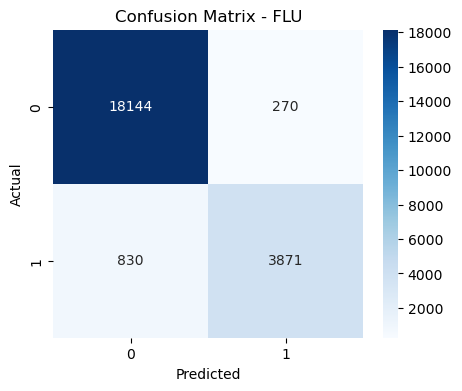

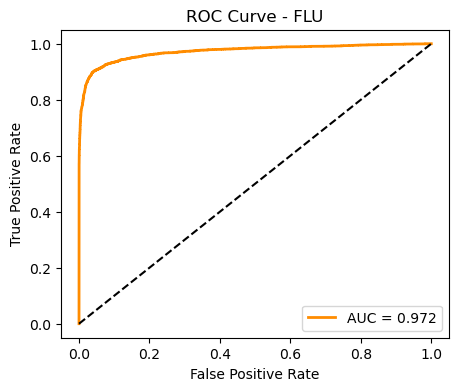

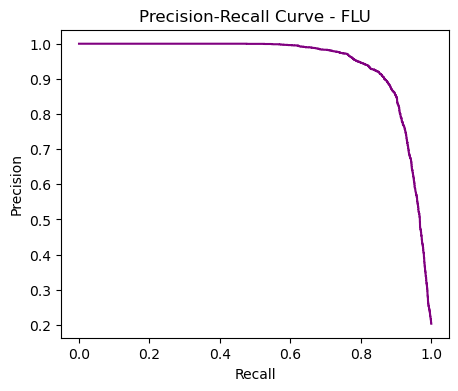

In [18]:
print("\n================ FLU MODEL TRAINING ================")
path_flu = "/Users/eeshanimaheshgundi/Downloads/flu_ml.csv"
flu = pd.read_csv(path_flu).dropna(subset=['SERIOUS'])


X = flu.drop(['SERIOUS','SYMPTOM1','SYMPTOM2','SYMPTOM3','SYMPTOM4','SYMPTOM5'], axis=1, errors='ignore')
y = flu['SERIOUS']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)


text_features = [col for col in X.columns if col in ['SYMPTOM_TEXT','OTHER_MEDS','CUR_ILL','HISTORY','ALLERGIES']]
categorical_features = [col for col in X.columns if X[col].dtype == 'object' and col not in text_features]


model_flu = CatBoostClassifier(
iterations=600,
depth=8,
learning_rate=0.05,
l2_leaf_reg=3,
random_state=42,
text_features=text_features,
cat_features=categorical_features,
loss_function='Logloss',
eval_metric='AUC',
verbose=100
)


start_train = time.time(); model_flu.fit(X_train, y_train); end_train = time.time()
start_pred = time.time(); y_pred = model_flu.predict(X_test); y_proba = model_flu.predict_proba(X_test)[:,1]; end_pred = time.time()


m_flu = get_metrics(y_test, y_pred, y_proba, end_train-start_train, end_pred-start_pred, "FLU")
metrics_all.append(m_flu)
pickle.dump(model_flu, open(f"{base_path}flu_catboost_model.sav", 'wb'))
pd.DataFrame({'True':y_test,'Pred':y_pred,'Proba':y_proba}).to_csv(f"{base_path}flu_predictions.csv",index=False)
fpr,tpr,_=roc_curve(y_test,y_proba)
plot_visuals("FLU", y_test, y_pred, y_proba)



================ VARZOS MODEL TRAINING ================
0:	total: 951ms	remaining: 9m 29s
100:	total: 1m 35s	remaining: 7m 51s
200:	total: 3m 7s	remaining: 6m 12s
300:	total: 4m 37s	remaining: 4m 35s
400:	total: 6m 11s	remaining: 3m 4s
500:	total: 7m 46s	remaining: 1m 32s
599:	total: 9m 22s	remaining: 0us


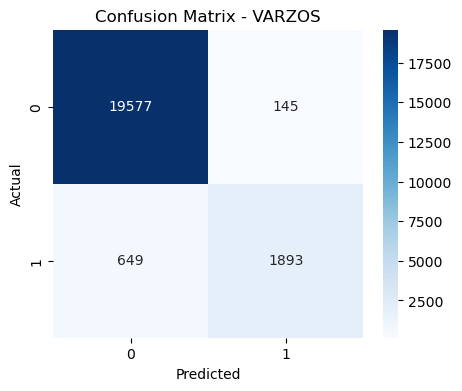

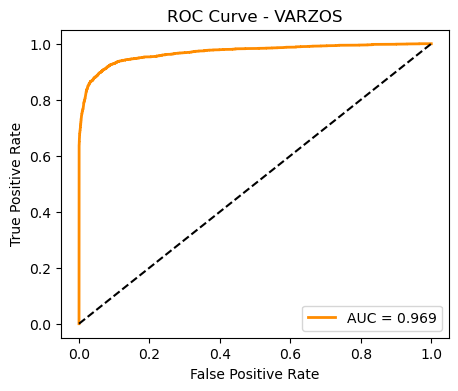

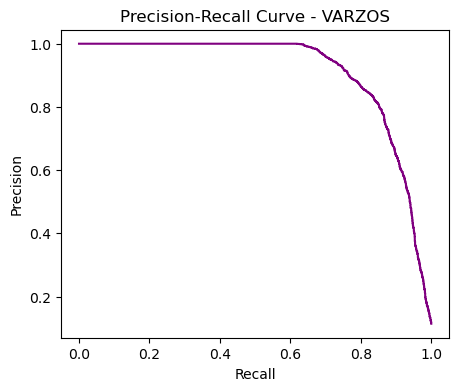

In [19]:
#============================================================
# 🧩 3️⃣ VARZOS Vaccine Model (Full Dataset)
# ============================================================
print("\n================ VARZOS MODEL TRAINING ================")
path_varzos = "/Users/eeshanimaheshgundi/Downloads/varzos_ml.csv"
varzos = pd.read_csv(path_varzos).dropna(subset=['SERIOUS'])


X = varzos.drop(['SERIOUS','SYMPTOM1','SYMPTOM2','SYMPTOM3','SYMPTOM4','SYMPTOM5'], axis=1, errors='ignore')
y = varzos['SERIOUS']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)


text_features = [col for col in X.columns if col in ['SYMPTOM_TEXT','OTHER_MEDS','CUR_ILL','HISTORY','ALLERGIES']]
categorical_features = [col for col in X.columns if X[col].dtype == 'object' and col not in text_features]


model_varzos = CatBoostClassifier(
iterations=600,
depth=8,
learning_rate=0.05,
l2_leaf_reg=3,
random_state=42,
text_features=text_features,
cat_features=categorical_features,
loss_function='Logloss',
eval_metric='AUC',
verbose=100
)


start_train = time.time(); model_varzos.fit(X_train, y_train); end_train = time.time()
start_pred = time.time(); y_pred = model_varzos.predict(X_test); y_proba = model_varzos.predict_proba(X_test)[:,1]; end_pred = time.time()


m_varzos = get_metrics(y_test, y_pred, y_proba, end_train-start_train, end_pred-start_pred, "VARZOS")
metrics_all.append(m_varzos)
pickle.dump(model_varzos, open(f"{base_path}varzos_catboost_model.sav", 'wb'))
pd.DataFrame({'True':y_test,'Pred':y_pred,'Proba':y_proba}).to_csv(f"{base_path}varzos_predictions.csv",index=False)
fpr,tpr,_=roc_curve(y_test,y_proba)
plot_visuals("VARZOS", y_test, y_pred, y_proba)





================ PPV MODEL TRAINING ================
0:	total: 834ms	remaining: 8m 19s
100:	total: 1m 19s	remaining: 6m 30s
200:	total: 2m 26s	remaining: 4m 51s
300:	total: 3m 36s	remaining: 3m 35s
400:	total: 4m 46s	remaining: 2m 22s
500:	total: 5m 55s	remaining: 1m 10s
599:	total: 7m 4s	remaining: 0us


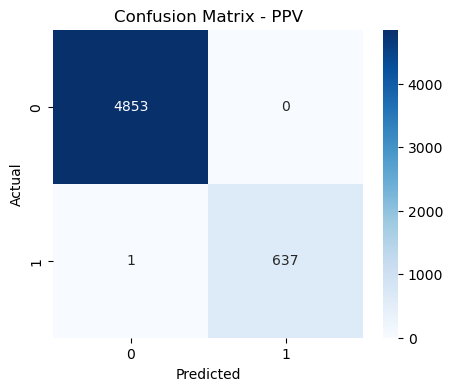

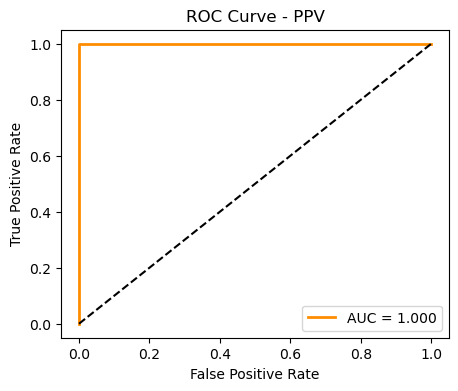

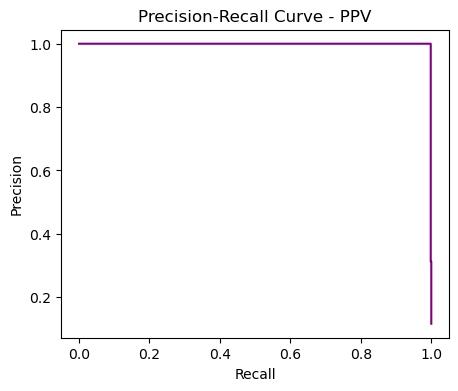

In [20]:
# ============================================================
# 🧩 4️⃣ PPV Vaccine Model (Full Dataset)
# ============================================================
print("\n================ PPV MODEL TRAINING ================")
path_ppv = "/Users/eeshanimaheshgundi/Downloads/ppv_ml.csv"
ppv = pd.read_csv(path_ppv).dropna(subset=['SERIOUS'])


X = ppv.drop(['SERIOUS','SYMPTOM1','SYMPTOM2','SYMPTOM3','SYMPTOM4','SYMPTOM5'], axis=1, errors='ignore')
y = ppv['SERIOUS']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)


text_features = [col for col in X.columns if col in ['SYMPTOM_TEXT','OTHER_MEDS','CUR_ILL','HISTORY','ALLERGIES']]
categorical_features = [col for col in X.columns if X[col].dtype == 'object' and col not in text_features]


model_ppv = CatBoostClassifier(
iterations=600,
depth=8,
learning_rate=0.05,
l2_leaf_reg=3,
random_state=42,
text_features=text_features,
cat_features=categorical_features,
loss_function='Logloss',
eval_metric='AUC',
verbose=100
)


start_train = time.time(); model_ppv.fit(X_train, y_train); end_train = time.time()
start_pred = time.time(); y_pred = model_ppv.predict(X_test); y_proba = model_ppv.predict_proba(X_test)[:,1]; end_pred = time.time()


m_ppv = get_metrics(y_test, y_pred, y_proba, end_train-start_train, end_pred-start_pred, "PPV")
metrics_all.append(m_ppv)
pickle.dump(model_ppv, open(f"{base_path}ppv_catboost_model.sav", 'wb'))
pd.DataFrame({'True':y_test,'Pred':y_pred,'Proba':y_proba}).to_csv(f"{base_path}ppv_predictions.csv",index=False)
fpr,tpr,_=roc_curve(y_test,y_proba)
plot_visuals("PPV", y_test, y_pred, y_proba)



================ COVID MODEL TRAINING ================


/var/folders/5v/z44vvh5d5x9cbysz6d64dtfr0000gn/T/ipykernel_80521/2596158118.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  covid = covid.groupby('SERIOUS', group_keys=False).apply(lambda x: x.sample(frac=0.4, random_state=42))


0:	total: 1.36s	remaining: 13m 35s
100:	total: 2m 30s	remaining: 12m 25s
200:	total: 4m 53s	remaining: 9m 43s
300:	total: 7m 21s	remaining: 7m 19s
400:	total: 9m 47s	remaining: 4m 51s
500:	total: 12m 13s	remaining: 2m 24s
599:	total: 14m 34s	remaining: 0us


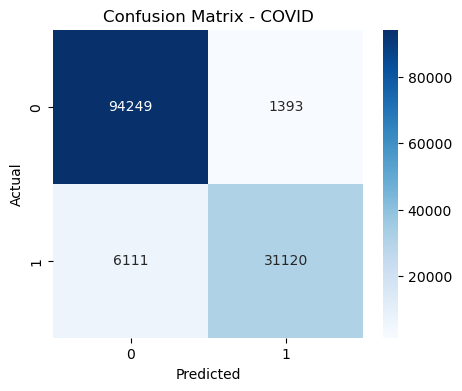

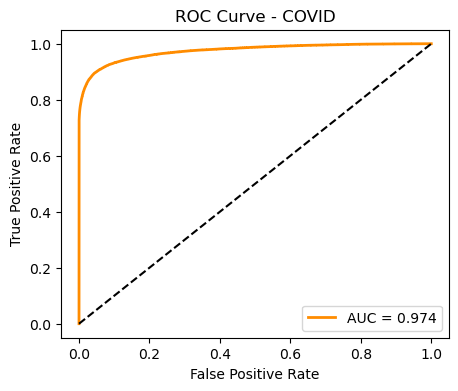

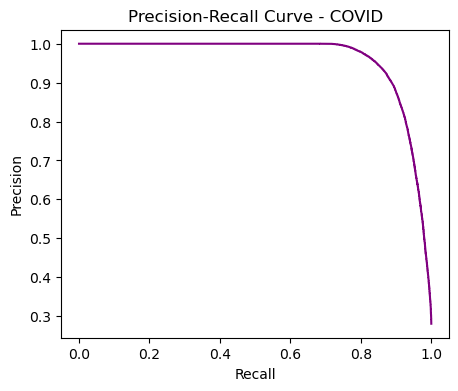

In [21]:
# ============================================================
# 🧩 1️⃣ COVID Vaccine Model (40% subset)
# ============================================================
print("\n================ COVID MODEL TRAINING ================")
path_covid = "/Users/eeshanimaheshgundi/Downloads/covid_ml.csv"
covid = pd.read_csv(path_covid).dropna(subset=['SERIOUS'])
covid = covid.groupby('SERIOUS', group_keys=False).apply(lambda x: x.sample(frac=0.4, random_state=42))


X = covid.drop(['SERIOUS','SYMPTOM1','SYMPTOM2','SYMPTOM3','SYMPTOM4','SYMPTOM5'], axis=1, errors='ignore')
y = covid['SERIOUS']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)


text_features = [col for col in X.columns if col in ['SYMPTOM_TEXT','OTHER_MEDS','CUR_ILL','HISTORY','ALLERGIES']]
categorical_features = [col for col in X.columns if X[col].dtype == 'object' and col not in text_features]


model_covid = CatBoostClassifier(
iterations=600,
depth=8,
learning_rate=0.05,
l2_leaf_reg=3,
random_state=42,
text_features=text_features,
cat_features=categorical_features,
loss_function='Logloss',
eval_metric='AUC',
verbose=100
)


start_train = time.time(); model_covid.fit(X_train, y_train); end_train = time.time()
start_pred = time.time(); y_pred = model_covid.predict(X_test); y_proba = model_covid.predict_proba(X_test)[:,1]; end_pred = time.time()


m_covid = get_metrics(y_test, y_pred, y_proba, end_train-start_train, end_pred-start_pred, "COVID")
metrics_all.append(m_covid)
pickle.dump(model_covid, open(f"{base_path}covid_catboost_model.sav", 'wb'))
pd.DataFrame({'True':y_test,'Pred':y_pred,'Proba':y_proba}).to_csv(f"{base_path}covid_predictions.csv",index=False)
fpr,tpr,_=roc_curve(y_test,y_proba)
plot_visuals("COVID", y_test, y_pred, y_proba)



📊 Combined Summary:


,Vaccine,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,MCC,Train Time (s),Predict Time (s)
0,FLU,0.952412,0.934798,0.823442,0.875594,0.972222,0.945090,0.848921,519.090000,0.240000
1,FLU,0.952412,0.934798,0.823442,0.875594,0.972222,0.945090,0.848921,545.200000,0.250000
2,VARZOS,0.964337,0.928852,0.744689,0.826638,0.969212,0.909708,0.813153,563.710000,0.270000
3,PPV,0.999818,1.000000,0.998433,0.999216,0.999548,0.998923,0.999113,424.730000,0.060000
4,COVID,0.943525,0.957156,0.835863,0.892407,0.974008,0.959797,0.857963,884.130000,1.640000


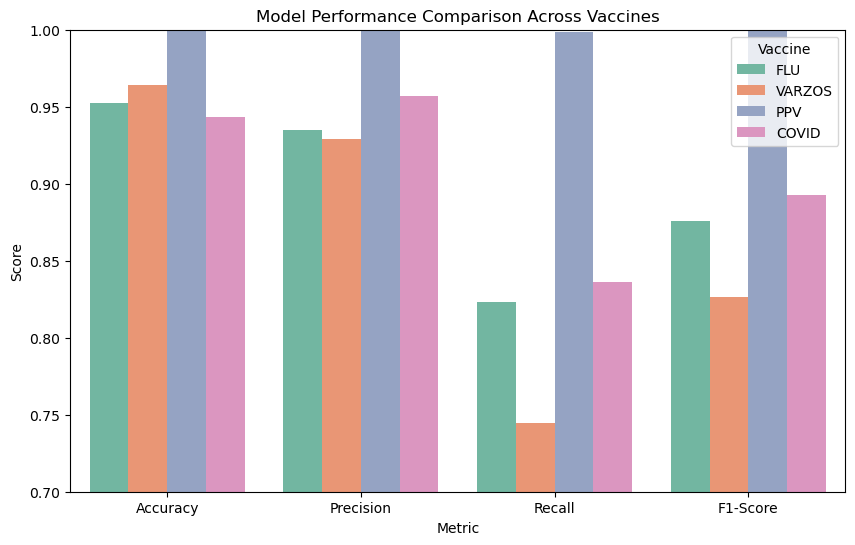

/var/folders/5v/z44vvh5d5x9cbysz6d64dtfr0000gn/T/ipykernel_80521/285246220.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Vaccine', y='Train Time (s)', palette='Blues_d')


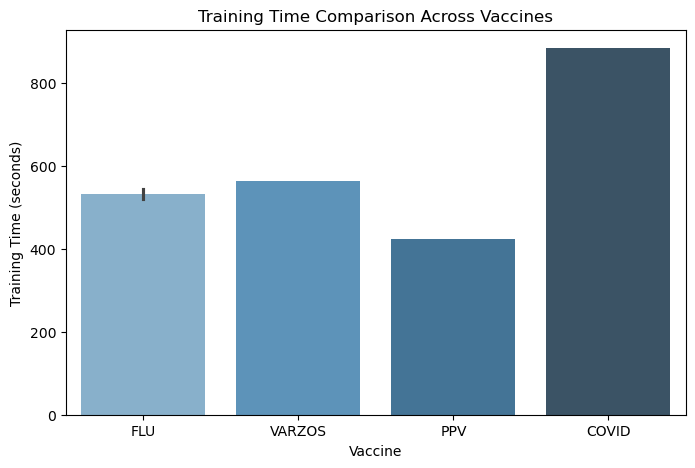


🎯 Phase 3 Text-Aware CatBoost Models Completed Successfully!


In [22]:
# ============================================================
# 🏁 Summary Comparison and Visualization
# ============================================================
results_df = pd.DataFrame(metrics_all)
results_df.to_csv(f"{base_path}catboost_vaccine_metrics_summary.csv", index=False)


print("\n📊 Combined Summary:")
display(results_df.style.background_gradient(cmap="YlGnBu").set_caption("CatBoost Summary Across Vaccines"))


plt.figure(figsize=(10,6))
sns.barplot(data=results_df.melt(id_vars='Vaccine', value_vars=['Accuracy','Precision','Recall','F1-Score']),
x='variable', y='value', hue='Vaccine', palette='Set2')
plt.title("Model Performance Comparison Across Vaccines")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Vaccine")
plt.ylim(0.7, 1.0)
plt.show()


plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x='Vaccine', y='Train Time (s)', palette='Blues_d')
plt.title("Training Time Comparison Across Vaccines")
plt.ylabel("Training Time (seconds)")
plt.show()


print("\n🎯 Phase 3 Text-Aware CatBoost Models Completed Successfully!")

In [23]:
import pandas as pd

# Load individual vaccine prediction CSVs
covid_pred = pd.read_csv(f"{base_path}covid_predictions.csv")
covid_pred["Vaccine"] = "COVID"

flu_pred = pd.read_csv(f"{base_path}flu_predictions.csv")
flu_pred["Vaccine"] = "FLU"

varzos_pred = pd.read_csv(f"{base_path}varzos_predictions.csv")
varzos_pred["Vaccine"] = "VARZOS"

ppv_pred = pd.read_csv(f"{base_path}ppv_predictions.csv")
ppv_pred["Vaccine"] = "PPV"

# Combine all into one DataFrame
combined_preds = pd.concat([covid_pred, flu_pred, varzos_pred, ppv_pred], ignore_index=True)

# Save to one unified file
combined_preds.to_csv(f"{base_path}combined_vaccine_predictions.csv", index=False)

print(f"✅ Combined predictions saved to: {base_path}combined_vaccine_predictions.csv")


✅ Combined predictions saved to: /Users/eeshanimaheshgundi/Documents/Sankalp Project/all_types_files/combined_vaccine_predictions.csv
